# NYC Airbnb Open Data — Exploratory Data Analysis

**Dataset:** New York City Airbnb listings, 2019  
**Source:** [Kaggle](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)  
**Author:** Bicher A

## Objective
Explore ~49,000 NYC Airbnb listings to understand price drivers, 
borough differences, room type trends, and host behaviour patterns.

## Loading & Checking Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('AB_NYC_2019.csv')

# First look
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (48895, 16)

Column names:
 ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data types:
 id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

First 5 r

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


## 1. Data Cleaning

In [3]:
# Fix last_review to datetime
df['last_review'] = pd.to_datetime(df['last_review'])

# Fill missing reviews_per_month with 0 (no reviews = 0 per month)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Drop rows where price = 0 (not real listings)
print("Listings with price = 0:", (df['price'] == 0).sum())
df = df[df['price'] > 0]

# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Confirm cleaned shape
print("Cleaned shape:", df.shape)

Listings with price = 0: 11
Duplicate rows: 0
Cleaned shape: (48884, 16)


## 2. Price Distribution

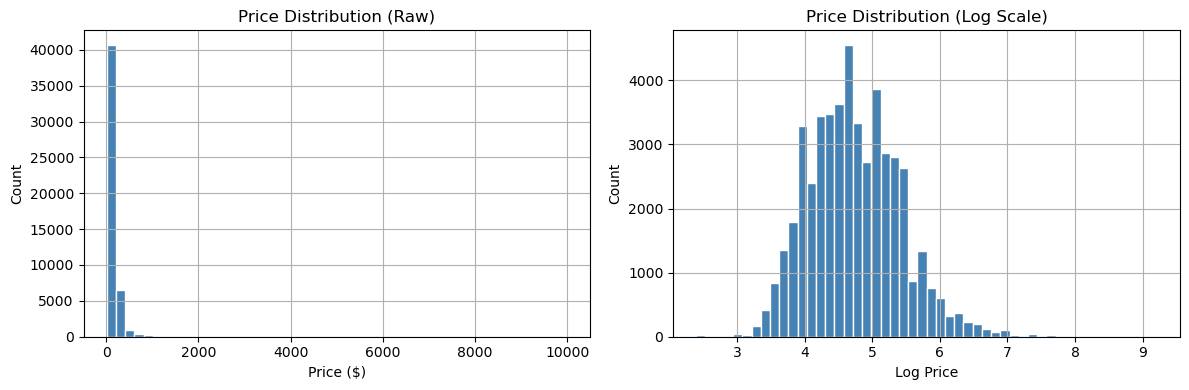

Price stats:
count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


In [4]:
plt.figure(figsize=(12,4))

# Raw price distribution
plt.subplot(1,2,1)
df['price'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Price Distribution (Raw)')
plt.xlabel('Price ($)')
plt.ylabel('Count')

# Log scale version
plt.subplot(1,2,2)
np.log1p(df['price']).hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Price Distribution (Log Scale)')
plt.xlabel('Log Price')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("Price stats:")
print(df['price'].describe())

## 3. Borough & Room Type Analysis

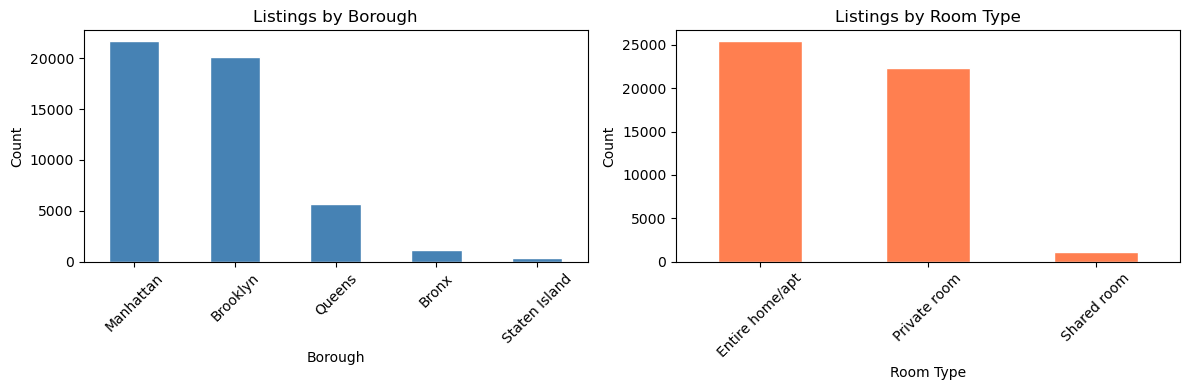

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Listings by borough
df['neighbourhood_group'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Listings by Borough')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Listings by room type
df['room_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Listings by Room Type')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

<Figure size 1200x500 with 0 Axes>

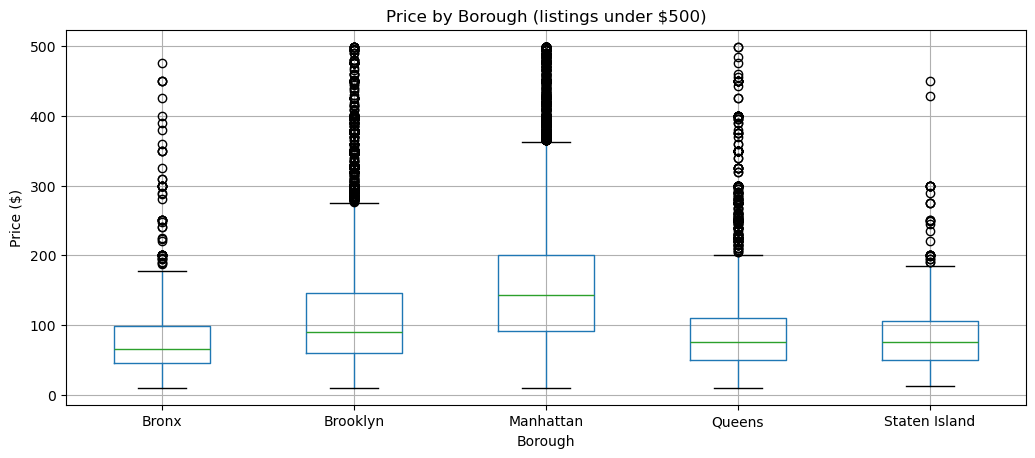

                           mean  median  count
neighbourhood_group                           
Manhattan            196.884903   150.0  21660
Brooklyn             124.438915    90.0  20095
Queens                99.517649    75.0   5666
Staten Island        114.812332    75.0    373
Bronx                 87.577064    65.0   1090


In [6]:
plt.figure(figsize=(12,5))

# Boxplot - price by borough (capped at 500 to see the boxes clearly)
df[df['price'] < 500].boxplot(
    column='price', by='neighbourhood_group', figsize=(12,5))
plt.title('Price by Borough (listings under $500)')
plt.suptitle('')  # removes default pandas title
plt.xlabel('Borough')
plt.ylabel('Price ($)')
plt.show()

# Mean and median table
print(df.groupby('neighbourhood_group')['price'].agg(['mean','median','count']).sort_values('median', ascending=False))

<Figure size 1000x500 with 0 Axes>

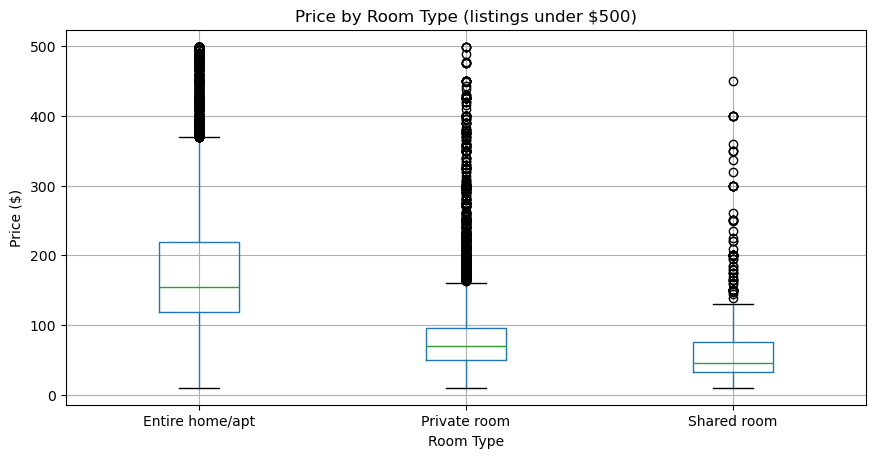

                       mean  median  count
room_type                                 
Entire home/apt  211.810918   160.0  25407
Private room      89.809131    70.0  22319
Shared room       70.248705    45.0   1158


In [7]:
plt.figure(figsize=(10,5))

df[df['price'] < 500].boxplot(
    column='price', by='room_type', figsize=(10,5))
plt.title('Price by Room Type (listings under $500)')
plt.suptitle('')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.show()

print(df.groupby('room_type')['price'].agg(['mean','median','count']).sort_values('median', ascending=False))

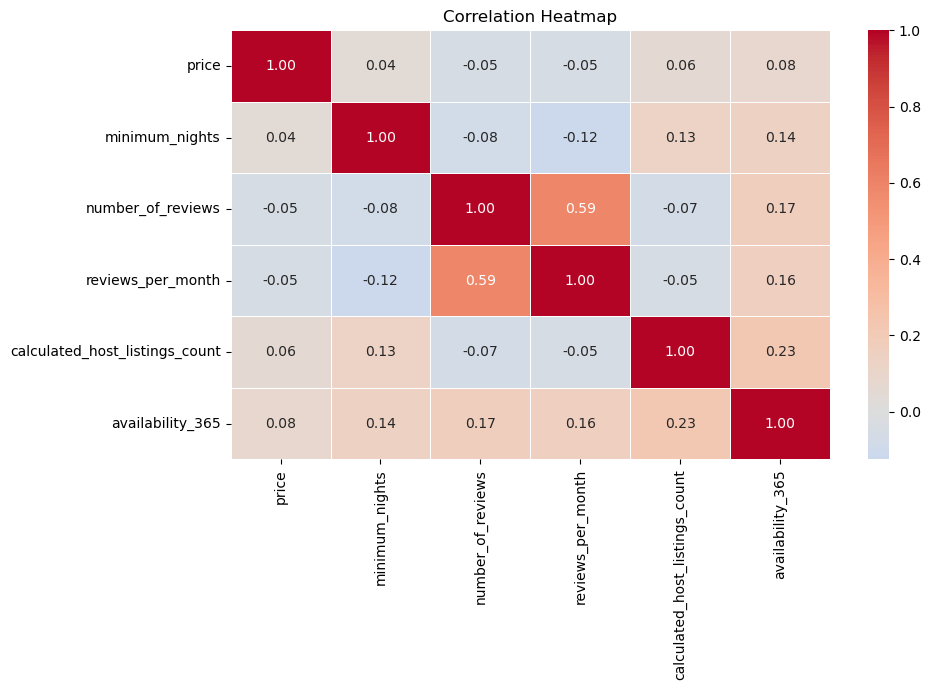

In [8]:
plt.figure(figsize=(10,7))
numeric_cols = ['price','minimum_nights','number_of_reviews',
                'reviews_per_month','calculated_host_listings_count','availability_365']

sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

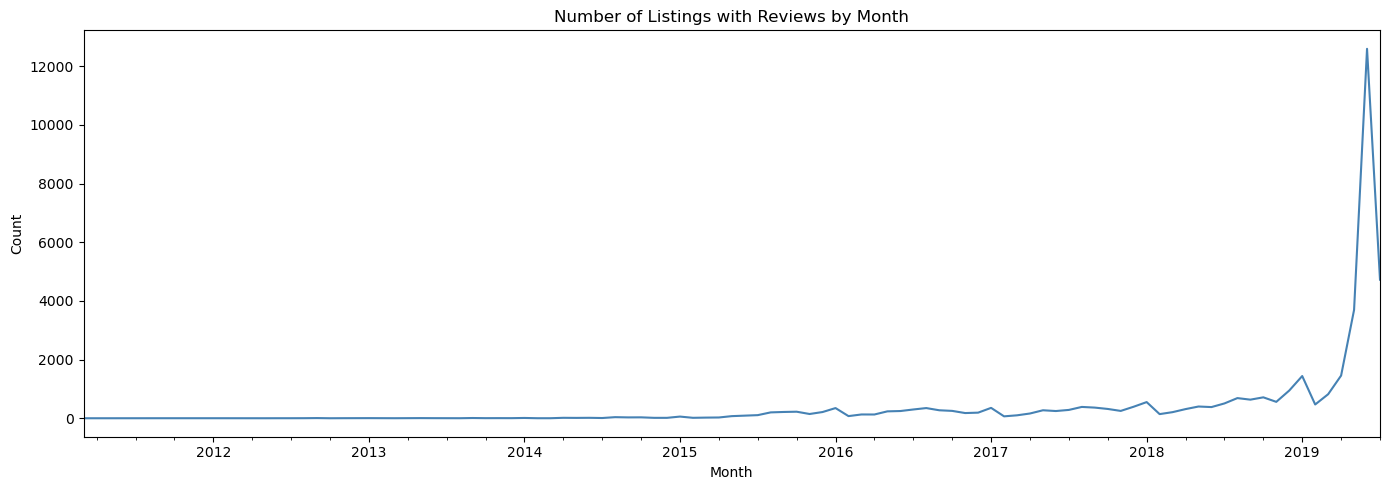

In [9]:
# Reviews over time (proxy for platform growth)
df['last_review'] = pd.to_datetime(df['last_review'])
reviews_over_time = df.dropna(subset=['last_review'])
reviews_over_time = reviews_over_time.groupby(
    reviews_over_time['last_review'].dt.to_period('M')).size()

plt.figure(figsize=(14,5))
reviews_over_time.plot(color='steelblue')
plt.title('Number of Listings with Reviews by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Geographic Distribution

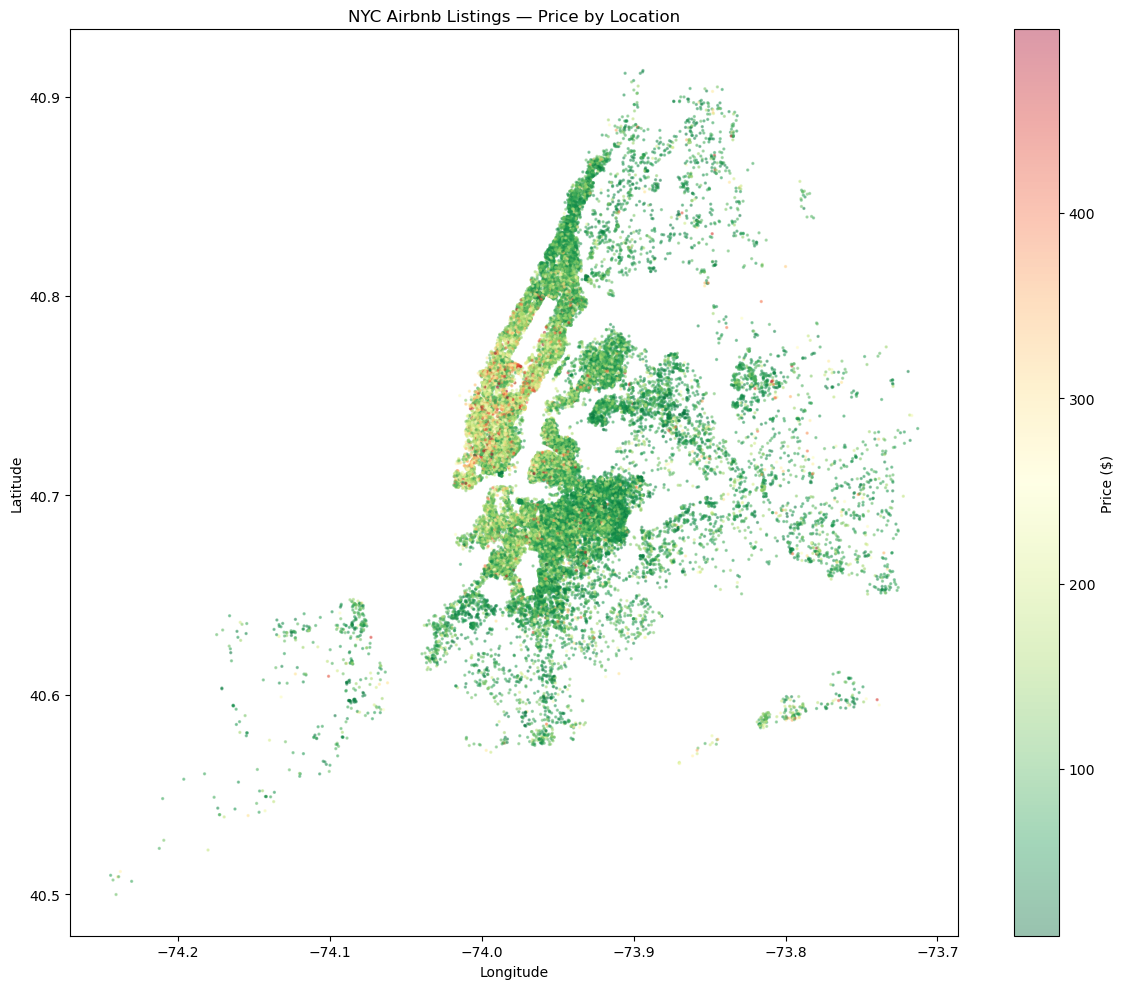

In [10]:
import matplotlib.pyplot as plt

# Cap price for better colour scaling
df_map = df[df['price'] < 500]

plt.figure(figsize=(12,10))
scatter = plt.scatter(
    df_map['longitude'], df_map['latitude'],
    c=df_map['price'], cmap='RdYlGn_r',
    alpha=0.4, s=2)
plt.colorbar(scatter, label='Price ($)')
plt.title('NYC Airbnb Listings — Price by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

## 6. Key Findings

|  | Theme | Finding |
|---|-------|---------|
| 1 | Price Distribution | Most listings are affordable — the median price is 106 USD per night. However the average is pulled up to 153 USD by a small number of luxury outliers, with some listings reaching 10,000 USD per night. Always look at the median, not the mean, for a true picture of this market. |
| 2 | Borough Breakdown | Where you stay in NYC matters more than anything else for price. Manhattan is the most expensive borough with a median of 150 USD per night — nearly double Brooklyn at 90 USD per night. The Bronx is the most affordable at 65 USD per night, yet has very few listings, suggesting an underserved market opportunity. |
| 3 | Room Types | Guests face a clear trade-off: entire homes offer privacy at a median of 160 USD per night, while private rooms cut that cost roughly in half at 70 USD per night. Shared rooms are the cheapest at 45 USD per night but barely exist — fewer than 1,200 listings out of 48,000 — suggesting guests strongly prefer not to share with strangers. |
| 4 | Price Drivers | Surprisingly, price is almost uncorrelated with how available a listing is, how many reviews it has, or how long the minimum stay is. This tells us that hosts do not lower prices to fill vacancies — instead, price is driven almost entirely by location and room type. |
| 5 | Platform Growth | Airbnb had almost no presence in NYC before 2014. From 2015 onwards the platform grew rapidly, with the vast majority of active listings receiving their most recent review in 2018 or 2019. This dataset captures Airbnb at near peak NYC adoption. |
| 6 | Host Behaviour | Not all hosts are individuals renting a spare room. A significant portion of listings belong to commercial operators running multiple properties simultaneously. These hosts tend to keep their listings available year-round, behaving more like hotels than casual home-sharers — a pattern that has attracted regulatory scrutiny in NYC. |

In [11]:
print("Dataset summary after cleaning:")
print(f"  Total listings analysed: {len(df):,}")
print(f"  Boroughs covered: {df['neighbourhood_group'].nunique()}")
print(f"  Unique neighbourhoods: {df['neighbourhood'].nunique()}")
print(f"  Price range: ${df['price'].min()} — ${df['price'].max():,}")
print(f"  Average price: ${df['price'].mean():.2f}")
print(f"  Date range: {df['last_review'].min().date()} to {df['last_review'].max().date()}")

Dataset summary after cleaning:
  Total listings analysed: 48,884
  Boroughs covered: 5
  Unique neighbourhoods: 221
  Price range: $10 — $10,000
  Average price: $152.76
  Date range: 2011-03-28 to 2019-07-08
